In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.pyplot import MultipleLocator
from math import sqrt
from numpy import concatenate
from pandas import read_csv, DataFrame, concat
from datetime import datetime
from sklearn.metrics import mean_squared_error

from sklearn.preprocessing import MinMaxScaler, StandardScaler

import keras.backend as K
from keras.layers import Multiply
from keras.models import Sequential ,Model
from keras.layers import Dense , Input , Reshape , Flatten ,Permute , Lambda , RepeatVector ,Conv1D , MaxPooling1D , Dropout, Bidirectional, Activation
from keras.layers import GRU, LSTM
from keras.utils.vis_utils import plot_model
from keras.optimizers import SGD,Adam
from keras.utils import np_utils   #np_utils
from keras.callbacks import TensorBoard  #TensorBoard可视化

Using TensorFlow backend.


In [2]:
# T:0
# H:1
# Surge:2
# Heave:4
# Force1:8
# 四级海况（波高2周期11.2水深50)
data_1 = pd.read_csv('14.2周期.csv')
data_1.head()

,T,H,Surge,Sway,Heave,Roll,Pitch,Yaw,Force1,Force2
0,0.1,918.0,-8.51,-0.00285,83.9,1.230000e-07,0.000726,3.900000e-08,5080.0,5120.0
1,0.2,823.0,-28.80,-0.02120,212.0,2.640000e-06,0.001920,1.490000e-06,5170.0,5340.0
2,0.3,726.0,-56.20,-0.04580,339.0,1.430000e-06,0.003260,5.200000e-06,5230.0,5580.0
3,0.4,631.0,-83.00,-0.06510,432.0,7.150000e-06,-0.000570,9.200000e-06,5230.0,5810.0
4,0.5,535.0,-99.10,-0.12200,474.0,1.200000e-05,-0.010200,9.980000e-06,5160.0,5980.0


In [3]:
data_1.describe()

,T,H,Surge,Sway,Heave,Roll,Pitch,Yaw,Force1,Force2
count,40000.000000,40000.000000,40000.000000,40000.000000,40000.000000,40000.000000,40000.000000,40000.000000,40000.000000,40000.000000
mean,2000.050030,-1.372035,36.647128,-0.077151,-28.680396,0.000002,-0.000367,-0.000011,5127.445720,4870.086250
std,1154.714989,1020.574059,405.340763,2.493557,981.152752,0.000406,0.036930,0.000400,2411.889486,574.013909
min,0.100000,-3020.000000,-1710.000000,-11.100000,-2970.000000,-0.002200,-0.133000,-0.003930,0.000000,1590.000000
25%,1000.075015,-708.000000,-202.000000,-1.650000,-706.000000,-0.000250,-0.025800,-0.000232,3510.000000,4580.000000
50%,2000.050030,0.943500,27.100000,-0.061850,-20.100000,0.000004,0.000504,-0.000007,5070.000000,4890.000000
75%,3000.025045,723.000000,266.000000,1.510000,663.000000,0.000258,0.025600,0.000213,6680.000000,5220.000000
max,4000.000060,3260.000000,1870.000000,15.100000,2970.000000,0.002500,0.129000,0.002710,14700.000000,8200.000000


In [4]:
data_distance = np.hstack((np.array(data_1)[:, 1:8], np.array(data_1)[:, 8:10]))
print(data_distance)
print(data_distance.shape)

[[ 9.18e+02 -8.51e+00 -2.85e-03 ...  3.90e-08  5.08e+03  5.12e+03]
 [ 8.23e+02 -2.88e+01 -2.12e-02 ...  1.49e-06  5.17e+03  5.34e+03]
 [ 7.26e+02 -5.62e+01 -4.58e-02 ...  5.20e-06  5.23e+03  5.58e+03]
 ...
 [-2.02e+03 -9.84e+02  2.67e+00 ... -9.64e-05  0.00e+00  6.08e+03]
 [-2.00e+03 -9.99e+02  2.40e+00 ... -1.91e-04  0.00e+00  6.13e+03]
 [-1.97e+03 -1.01e+03  2.24e+00 ... -5.77e-05  0.00e+00  6.18e+03]]
(40000, 9)


In [5]:
H_scaler = MinMaxScaler(feature_range=(-1, 1))
H = H_scaler.fit_transform(data_distance[:,0:1])
Surge_scaler = MinMaxScaler(feature_range=(-1, 1))
Surge = Surge_scaler.fit_transform(data_distance[:,1:2])
Sway_scaler = MinMaxScaler(feature_range=(-1, 1))
Sway = Sway_scaler.fit_transform(data_distance[:,2:3])
Heave_scaler = MinMaxScaler(feature_range=(-1, 1))
Heave = Heave_scaler.fit_transform(data_distance[:,3:4])
Roll_scaler = MinMaxScaler(feature_range=(-1, 1))
Roll = Roll_scaler.fit_transform(data_distance[:,4:5]*1e6)
Pitch_scaler = MinMaxScaler(feature_range=(-1, 1))
Pitch = Pitch_scaler.fit_transform(data_distance[:,5:6])
Yaw_scaler = MinMaxScaler(feature_range=(-1, 1))
Yaw = Yaw_scaler.fit_transform(data_distance[:,6:7]*1e6)
Force1_scaler = MinMaxScaler(feature_range=(-1, 1))
Force1 = Force1_scaler.fit_transform(data_distance[:,7:8])
Force2_scaler = MinMaxScaler(feature_range=(-1, 1))
Force2 = Force2_scaler.fit_transform(data_distance[:,8:9])
# zong_data = np.hstack(())

In [6]:
def series_to_supervised(data, n_in, n_out, dropnan=True):
#      '''
#      说明：将每一个特征（输入+输出）的单步-目标步长数全数列举出来
#      '''
    n_vars = 1 if type(data) is list else data.shape[1]
    df = DataFrame(data)
    cols, names = list(), list()
    for i in range(n_in, 0, -1):
        cols.append(df.shift(i))
        names += [('var%d(t-%d)' % (j+1, i)) for j in range(n_vars)]
    for i in range(0, n_out):
        cols.append(df.shift(-i))
        if i == 0:
            names += [('var%d(t)' % (j+1)) for j in range(n_vars)]
        else:
            names += [('var%d(t+%d)' % (j+1, i)) for j in range(n_vars)]
    agg = concat(cols, axis=1)
    agg.columns = names
    if dropnan:
        agg.dropna(inplace=True)
    return agg
def deal_data1(data, features_number, time_steps):
    '''
    适用：单/多特征，单/多预测步长
    data：数据集（仅包括输入+输出，且输出仅有一列并在最后）
    feature_number：输入+输出变量数
    n_in：预测步长
    结果解释：输入+输出+所需预测步长的输出（当为单特征时，输入、输出为同一列）
    '''
    process_data = series_to_supervised(data, time_steps, 1, dropnan=True)
    a = []
    for i in range(features_number, features_number*(time_steps+1)-1):
        a.append(i)
        i = i+1
    process_data.drop(process_data.columns[a], axis=1, inplace=True)
    return process_data.values
def deal_data2(data, features_number, time_steps):
    '''
    适用：多特征，单/多预测步长，不适用于单特征
    data：数据集（仅包括输入+输出，且输出仅有一列并在最后）
    feature_number：输入+输出变量数
    n_in：预测步长
    结果解释：输入+所需预测步长的输出
    '''
    process_data = series_to_supervised(data, time_steps, 1, dropnan=True)
    a = []
    for i in range(features_number-1, features_number*(time_steps+1)-1):
        a.append(i)
        i = i+1
    process_data.drop(process_data.columns[a], axis=1, inplace=True)
    return process_data.values
def split_sequence(dataset, n_past):
    x, y = list(), list()
    for i in range(len(dataset)):
        end_ix = i + n_past
        if end_ix > len(dataset):
            break
        seq_x, seq_y = dataset[i:end_ix, :-1], dataset[i, -1]
        x.append(seq_x)
        y.append(seq_y)
    return np.array(x), np.array(y)

def loss_plot(history, epo, length, width):
    # plot history
    plt.figure(figsize = (length, width))
    # 将x周的刻度线方向设置向内
    plt.rcParams['xtick.direction'] = 'in'  
    # 将y轴的刻度方向设置向内
    plt.rcParams['ytick.direction'] = 'in'  
    #设置字体以便支持中文
    plt.rcParams['font.sans-serif']=['SimHei']
    #为正常显示负号
    plt.rcParams['axes.unicode_minus'] = False 
    plt.plot(history.history['loss'], label = 'train loss')
    plt.plot(history.history['val_loss'], label = 'valid loss')
    plt.title('Model loss')
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend()
    plt.show()
    print(np.hstack((np.array(history.history['loss']).reshape(epo,1), np.array(history.history['val_loss']).reshape(epo,1))))

from sklearn.metrics import r2_score,mean_squared_error,mean_absolute_error,mean_absolute_percentage_error
def RNSE(valid_y,pre_Y):
    XP1 = valid_y.copy()
    XA1 = pre_Y.copy()
    print('RMSE(sklearn):',np.sqrt(mean_squared_error(XP1, XA1)))

def Acc(valid_y,pre_Y):
    XP1 = valid_y.copy()
    XA1 = pre_Y.copy()
    real1 = np.trapz(abs((XP1 - (XP1.sum()/(XP1.shape[0])))).reshape(XP1.shape[0],), dx=0.1)
    pre1 = np.trapz(abs((XA1 - (XP1.sum()/(XP1.shape[0])))).reshape(XA1.shape[0],), dx=0.1)
    Acc1 = 1 - abs(1 - (pre1/real1))
    print('Acc:', Acc1)

def FanGuiHua_surge(valid_sur_y,sur_pre_Y):
    fan_surge_real=Surge_scaler.inverse_transform(valid_sur_y)
    fan_surge_pre=Surge_scaler.inverse_transform(sur_pre_Y)
    plt.figure(figsize=(30,4), dpi=100)
    plt.plot(fan_surge_real[:200],color='blue',label='real')   #真实曲线
    plt.plot(fan_surge_pre[:200],color='orange',label='prediction') #预测曲线
    plt.legend()
    plt.show()
#     evaluate(fan_surge_real,fan_surge_pre)
    return fan_surge_real,fan_surge_pre
def FanGuiHua_pitch(valid_pit_y,pit_pre_Y):
    fan_pitch_real=Pitch_scaler.inverse_transform(valid_pit_y)
    fan_pitch_pre=Pitch_scaler.inverse_transform(pit_pre_Y)
    plt.figure(figsize=(30,4), dpi=100)
    plt.plot(fan_pitch_real[:200],color='blue',label='real')   #真实曲线
    plt.plot(fan_pitch_pre[:200],color='orange',label='prediction') #预测曲线
    plt.legend()
    plt.show()
#     evaluate(fan_pitch_real,fan_pitch_pre)
    return fan_pitch_real,fan_pitch_pre
def FanGuiHua_sway(valid_sway_y,sway_pre_Y):
    fan_sway_real=Sway_scaler.inverse_transform(valid_sway_y)
    fan_sway_pre=Sway_scaler.inverse_transform(sway_pre_Y)
    plt.figure(figsize=(30,4), dpi=100)
    plt.plot(fan_sway_real[:200],color='blue',label='real')   #真实曲线
    plt.plot(fan_sway_pre[:200],color='orange',label='prediction') #预测曲线
    plt.legend()
    plt.show()
#     evaluate(fan_sway_real,fan_sway_pre)
    return fan_sway_real,fan_sway_pre
def FanGuiHua_roll(valid_roll_y,roll_pre_Y):
    fan_roll_real=Roll_scaler.inverse_transform(valid_roll_y)
    fan_roll_pre=Roll_scaler.inverse_transform(roll_pre_Y)
    plt.figure(figsize=(30,4), dpi=100)
    plt.plot(fan_roll_real[:200],color='blue',label='real')   #真实曲线
    plt.plot(fan_roll_pre[:200],color='orange',label='prediction') #预测曲线
    plt.legend()
    plt.show()
#     evaluate(fan_roll_real,fan_roll_pre)
    return fan_roll_real,fan_roll_pre
def FanGuiHua_yaw(valid_yaw_y,yaw_pre_Y):
    fan_yaw_real=Yaw_scaler.inverse_transform(valid_yaw_y)
    fan_yaw_pre=Yaw_scaler.inverse_transform(yaw_pre_Y)
    plt.figure(figsize=(30,4), dpi=100)
    plt.plot(fan_yaw_real[:200],color='blue',label='real')   #真实曲线
    plt.plot(fan_yaw_pre[:200],color='orange',label='prediction') #预测曲线
    plt.legend()
    plt.show()
#     evaluate(fan_yaw_real,fan_yaw_pre)
    return fan_yaw_real,fan_yaw_pre
def FanGuiHua_heave(valid_hea_y,hea_pre_Y):
    fan_heave_real=Heave_scaler.inverse_transform(valid_hea_y)
    fan_heave_pre=Heave_scaler.inverse_transform(hea_pre_Y)
    plt.figure(figsize=(30,4), dpi=100)
    plt.plot(fan_heave_real[:200],color='blue',label='real')   #真实曲线
    plt.plot(fan_heave_pre[:200],color='orange',label='prediction') #预测曲线
    plt.legend()
    plt.show()
#     evaluate(fan_heave_real,fan_heave_pre)
    return fan_heave_real,fan_heave_pre
def FanGuiHua_force1(valid_for1_y,for1_pre_Y):
    fan_force1_real=Force1_scaler.inverse_transform(valid_for1_y)
    fan_force1_pre=Force1_scaler.inverse_transform(for1_pre_Y)
    plt.figure(figsize=(30,4), dpi=100)
    plt.plot(fan_force1_real,color='blue',label='real')   #真实曲线
    plt.plot(fan_force1_pre,color='orange',label='prediction') #预测曲线
    plt.legend()
    plt.show()
#     evaluate(fan_force1_real,fan_force1_pre)
    return fan_force1_real,fan_force1_pre
def FanGuiHua_force2(valid_for2_y,for2_pre_Y):
    fan_force2_real=Force2_scaler.inverse_transform(valid_for2_y)
    fan_force2_pre=Force2_scaler.inverse_transform(for2_pre_Y)
    plt.figure(figsize=(30,4), dpi=100)
    plt.plot(fan_force2_real,color='blue',label='real')   #真实曲线
    plt.plot(fan_force2_pre,color='orange',label='prediction') #预测曲线
    plt.legend()
    plt.show()
#     evaluate(fan_force2_real,fan_force2_pre)
    return fan_force2_real,fan_force2_pre

# 训练量=n_train_times_end-n_train_times_start
def split_train_valid(data_X, data_Y, n_train_times_start, n_train_times_end, n_valid_times):
    '''
    说明：将数据集划分为训练集和验证集
    疑问：先数据切割重组再划分数据集，先划分数据集再数据切割重组，有何区别影响？
    '''
    train_x, valid_x = data_X[n_train_times_start:n_train_times_end, :], data_X[n_train_times_end:n_valid_times, :]
    train_y, valid_y = data_Y[n_train_times_start:n_train_times_end], data_Y[n_train_times_end:n_valid_times]
    train_y = train_y.reshape((n_train_times_end-n_train_times_start, 1))
    valid_y = valid_y.reshape((n_valid_times-n_train_times_end, 1))
    return train_x, train_y, valid_x, valid_y

In [7]:
def Model_NN1(train_X, train_Y, valid_X, valid_Y, feature_number, lr=0.01, epochs=20, batch_size=256):
    input_layer = Input(shape=(feature_number,)) 
    D_layer1 = Dense(units = 150, activation = 'tanh')(input_layer)
    D_layer2 = Dense(units = 150, activation = 'tanh')(D_layer1)
    D_layer3 = Dense(units = 150, activation = 'tanh')(D_layer2)
    output_layer = Dense(1, activation = 'linear')(D_layer2)
    model = Model(inputs = input_layer, outputs = output_layer)
    adam = Adam(lr = lr)
    model.compile(loss='mse', optimizer='adam')
    history = model.fit(train_X, train_Y, epochs=epochs, batch_size=batch_size, validation_data=(valid_X, valid_Y), verbose=2, shuffle=False)
    model_structure = model.summary()
    pre_train_Y = model.predict(train_X)
    pre_Y = model.predict(valid_X)
    return model, history, pre_train_Y, pre_Y

In [8]:
def Model_NN(train_X, train_Y, valid_X, valid_Y, lr=0.01, epochs=20, batch_size=256):
    model = Sequential() #初始化模型
    model.add(Dense(150,input_shape=(train_X.shape[1], ),activation='tanh')) #添加一个隐含层，注：只是第一个隐含层需指定input_dim
    model.add(Dense(150,activation='tanh'))
    model.add(Dense(150,activation='tanh'))
    model.add(Dense(1,activation='linear')) #添加输出层
    adam = Adam(lr = lr)
    model.compile(loss='mse', optimizer='adam')
    history = model.fit(train_X, train_Y, epochs=epochs, batch_size=batch_size, validation_data=(valid_X, valid_Y), verbose=2, shuffle=False)
    model_structure = model.summary()
    pre_train_Y = model.predict(train_X)
    pre_Y = model.predict(valid_X)
    return model, history, pre_train_Y, pre_Y

In [9]:
# 归一化后的两个数据集
# 波浪-运动响应
# Force
# 输入500步长输出10步长
force150_scaled1 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[3500:,:], 4, 509)
force150_x1,force150_y1 = split_sequence(force150_scaled1, 500)
print(force150_x1.shape)
# # 输入100步长输出1步长
# force1100_scaled1 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[300:,:], 4, 100)
# force1100_x1,force1100_y1 = split_sequence(force1100_scaled1, 100)
# print(force1100_x1.shape)



# 输入500步长输出30步长
force150_scaled3 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[3480:,:], 4, 529)
force150_x3,force150_y3 = split_sequence(force150_scaled3, 500)
print(force150_x3.shape)
# # 输入100步长输出3步长
# force1100_scaled3 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[298:,:], 4, 102)
# force1100_x3,force1100_y3 = split_sequence(force1100_scaled3, 100)
# print(force1100_x3.shape)



# # 输入50步长输出5步长
# force150_scaled5 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[346:,:], 4, 54)
# force150_x5,force150_y5 = split_sequence(force150_scaled5, 50)
# print(force150_x5.shape)
# # 输入100步长输出5步长
# force1100_scaled5 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[296:,:], 4, 104)
# force1100_x5,force1100_y5 = split_sequence(force1100_scaled5, 100)
# print(force1100_x5.shape)



# # 输入50步长输出7步长
# force150_scaled7 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[344:,:], 4, 56)
# force150_x7,force150_y7 = split_sequence(force150_scaled7, 50)
# print(force150_x7.shape)
# # 输入100步长输出7步长
# force1100_scaled7 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[294:,:], 4, 106)
# force1100_x7,force1100_y7 = split_sequence(force1100_scaled7, 100)
# print(force1100_x7.shape)



# # 输入50步长输出9步长
# force150_scaled9 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[342:,:], 4, 58)
# force150_x9,force150_y9 = split_sequence(force150_scaled9, 50)
# print(force150_x9.shape)
# # 输入100步长输出9步长
# force1100_scaled9 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[292:,:], 4, 108)
# force1100_x9,force1100_y9 = split_sequence(force1100_scaled9, 100)
# print(force1100_x9.shape)



# 输入500步长输出20步长
force150_scaled2 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[3490:,:], 4, 519)
force150_x2,force150_y2 = split_sequence(force150_scaled2, 500)
print(force150_x2.shape)
# # 输入100步长输出2步长
# force1100_scaled2 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[299:,:], 4, 101)
# force1100_x2,force1100_y2 = split_sequence(force1100_scaled2, 100)
# print(force1100_x2.shape)


# 输入500步长输出40步长
force150_scaled4 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[3470:,:], 4, 539)
force150_x4,force150_y4 = split_sequence(force150_scaled4, 500)
print(force150_x4.shape)
# # 输入100步长输出4步长
# force1100_scaled4 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[297:,:], 4, 103)
# force1100_x4,force1100_y4 = split_sequence(force1100_scaled4, 100)
# print(force1100_x4.shape)



# # 输入50步长输出6步长
# force150_scaled6 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[345:,:], 4, 55)
# force150_x6,force150_y6 = split_sequence(force150_scaled6, 50)
# print(force150_x6.shape)
# # 输入100步长输出6步长
# force1100_scaled6 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[295:,:], 4, 105)
# force1100_x6,force1100_y6 = split_sequence(force1100_scaled6, 100)
# print(force1100_x6.shape)



# # 输入50步长输出8步长
# force150_scaled8 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[343:,:], 4, 57)
# force150_x8,force150_y8 = split_sequence(force150_scaled8, 50)
# print(force150_x8.shape)
# # 输入100步长输出8步长
# force1100_scaled8 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[293:,:], 4, 107)
# force1100_x8,force1100_y8 = split_sequence(force1100_scaled8, 100)
# print(force1100_x8.shape)

(35492, 500, 3)
(35492, 500, 3)
(35492, 500, 3)
(35492, 500, 3)


In [10]:
print(force150_y1)
print(force150_y2)
print(force150_y3)
print(force150_y4)

[0.89115646 0.87755102 0.86394558 ... 0.17006803 0.15918367 0.14829932]
[0.89115646 0.87755102 0.86394558 ... 0.17006803 0.15918367 0.14829932]
[0.89115646 0.87755102 0.86394558 ... 0.17006803 0.15918367 0.14829932]
[0.89115646 0.87755102 0.86394558 ... 0.17006803 0.15918367 0.14829932]


In [11]:
# 归一化后的两个数据集
# 波浪-运动响应
# 归一化后的两个数据集
# 波浪-运动响应
# Heave
# 输入500步长输出10步长
heave50_scaled1 = deal_data2(np.hstack((H,Heave))[3500:,:], 2, 509)
heave50_x1,heave50_y1 = split_sequence(heave50_scaled1, 500)
print(heave50_x1.shape)
# # 输入100步长输出1步长
# heave100_scaled1 = deal_data2(np.hstack((H,Heave))[300:,:], 2, 100)
# heave100_x1,heave100_y1 = split_sequence(heave100_scaled1, 100)
# print(heave100_x1.shape)



# 输入500步长输出30步长
heave50_scaled3 = deal_data2(np.hstack((H,Heave))[3480:,:], 2, 529)
heave50_x3,heave50_y3 = split_sequence(heave50_scaled3, 500)
print(heave50_x3.shape)
# # 输入100步长输出3步长
# heave100_scaled3 = deal_data2(np.hstack((H,Heave))[298:,:], 2, 102)
# heave100_x3,heave100_y3 = split_sequence(heave100_scaled3, 100)
# print(heave100_x3.shape)



# # 输入50步长输出5步长
# heave50_scaled5 = deal_data2(np.hstack((H,Heave))[346:,:], 2, 54)
# heave50_x5,heave50_y5 = split_sequence(heave50_scaled5, 50)
# print(heave50_x5.shape)
# # 输入100步长输出5步长
# heave100_scaled5 = deal_data2(np.hstack((H,Heave))[296:,:], 2, 104)
# heave100_x5,heave100_y5 = split_sequence(heave100_scaled5, 100)
# print(heave100_x5.shape)



# # 输入50步长输出7步长
# heave50_scaled7 = deal_data2(np.hstack((H,Heave))[344:,:], 2, 56)
# heave50_x7,heave50_y7 = split_sequence(heave50_scaled7, 50)
# print(heave50_x7.shape)
# # 输入100步长输出7步长
# heave100_scaled7 = deal_data2(np.hstack((H,Heave))[294:,:], 2, 106)
# heave100_x7,heave100_y7 = split_sequence(heave100_scaled7, 100)
# print(heave100_x7.shape)



# # 输入50步长输出9步长
# heave50_scaled9 = deal_data2(np.hstack((H,Heave))[342:,:], 2, 58)
# heave50_x9,heave50_y9 = split_sequence(heave50_scaled9, 50)
# print(heave50_x9.shape)
# # 输入100步长输出9步长
# heave100_scaled9 = deal_data2(np.hstack((H,Heave))[292:,:], 2, 108)
# heave100_x9,heave100_y9 = split_sequence(heave100_scaled9, 100)
# print(heave100_x9.shape)



# 输入500步长输出20步长
heave50_scaled2 = deal_data2(np.hstack((H,Heave))[3490:,:], 2, 519)
heave50_x2,heave50_y2 = split_sequence(heave50_scaled2, 500)
print(heave50_x2.shape)
# # 输入100步长输出2步长
# heave100_scaled2 = deal_data2(np.hstack((H,Heave))[299:,:], 2, 101)
# heave100_x2,heave100_y2 = split_sequence(heave100_scaled2, 100)
# print(heave100_x2.shape)


# 输入500步长输出40步长
heave50_scaled4 = deal_data2(np.hstack((H,Heave))[3470:,:], 2, 539)
heave50_x4,heave50_y4 = split_sequence(heave50_scaled4, 500)
print(heave50_x4.shape)
# # 输入100步长输出4步长
# heave100_scaled4 = deal_data2(np.hstack((H,Heave))[297:,:], 2, 103)
# heave100_x4,heave100_y4 = split_sequence(heave100_scaled4, 100)
# print(heave100_x4.shape)



# # 输入50步长输出6步长
# heave50_scaled6 = deal_data2(np.hstack((H,Heave))[345:,:], 2, 55)
# heave50_x6,heave50_y6 = split_sequence(heave50_scaled6, 50)
# print(heave50_x6.shape)
# # 输入100步长输出6步长
# heave100_scaled6 = deal_data2(np.hstack((H,Heave))[295:,:], 2, 105)
# heave100_x6,heave100_y6 = split_sequence(heave100_scaled6, 100)
# print(heave100_x6.shape)



# # 输入50步长输出8步长
# heave50_scaled8 = deal_data2(np.hstack((H,Heave))[343:,:], 2, 57)
# heave50_x8,heave50_y8 = split_sequence(heave50_scaled8, 50)
# print(heave50_x8.shape)
# # 输入100步长输出8步长
# heave100_scaled8 = deal_data2(np.hstack((H,Heave))[293:,:], 2, 107)
# heave100_x8,heave100_y8 = split_sequence(heave100_scaled8, 100)
# print(heave100_x8.shape)


# Surge
# 输入500步长输出10步长
surge50_scaled1 = deal_data2(np.hstack((H,Surge))[3500:,:], 2, 509)
surge50_x1,surge50_y1 = split_sequence(surge50_scaled1, 500)
print(surge50_x1.shape)
# # 输入100步长输出1步长
# surge100_scaled1 = deal_data2(np.hstack((H,Surge))[300:,:], 2, 100)
# surge100_x1,surge100_y1 = split_sequence(surge100_scaled1, 100)
# print(surge100_x1.shape)



# 输入500步长输出30步长
surge50_scaled3 = deal_data2(np.hstack((H,Surge))[3480:,:], 2, 529)
surge50_x3,surge50_y3 = split_sequence(surge50_scaled3, 500)
print(surge50_x3.shape)
# # 输入100步长输出3步长
# surge100_scaled3 = deal_data2(np.hstack((H,Surge))[298:,:], 2, 102)
# surge100_x3,surge100_y3 = split_sequence(surge100_scaled3, 100)
# print(surge100_x3.shape)



# # 输入50步长输出5步长
# surge50_scaled5 = deal_data2(np.hstack((H,Surge))[346:,:], 2, 54)
# surge50_x5,surge50_y5 = split_sequence(surge50_scaled5, 50)
# print(surge50_x5.shape)
# # 输入100步长输出5步长
# surge100_scaled5 = deal_data2(np.hstack((H,Surge))[296:,:], 2, 104)
# surge100_x5,surge100_y5 = split_sequence(surge100_scaled5, 100)
# print(surge100_x5.shape)



# # 输入50步长输出7步长
# surge50_scaled7 = deal_data2(np.hstack((H,Surge))[344:,:], 2, 56)
# surge50_x7,surge50_y7 = split_sequence(surge50_scaled7, 50)
# print(surge50_x7.shape)
# # 输入100步长输出7步长
# surge100_scaled7 = deal_data2(np.hstack((H,Surge))[294:,:], 2, 106)
# surge100_x7,surge100_y7 = split_sequence(surge100_scaled7, 100)
# print(surge100_x7.shape)



# # 输入50步长输出9步长
# surge50_scaled9 = deal_data2(np.hstack((H,Surge))[342:,:], 2, 58)
# surge50_x9,surge50_y9 = split_sequence(surge50_scaled9, 50)
# print(surge50_x9.shape)
# # 输入100步长输出9步长
# surge100_scaled9 = deal_data2(np.hstack((H,Surge))[292:,:], 2, 108)
# surge100_x9,surge100_y9 = split_sequence(surge100_scaled9, 100)
# print(surge100_x9.shape)



# 输入500步长输出20步长
surge50_scaled2 = deal_data2(np.hstack((H,Surge))[3490:,:], 2, 519)
surge50_x2,surge50_y2 = split_sequence(surge50_scaled2, 500)
print(surge50_x2.shape)
# 输入100步长输出2步长
# surge100_scaled2 = deal_data2(np.hstack((H,Surge))[299:,:], 2, 101)
# surge100_x2,surge100_y2 = split_sequence(surge100_scaled2, 100)
# print(surge100_x2.shape)


# 输入500步长输出40步长
surge50_scaled4 = deal_data2(np.hstack((H,Surge))[3470:,:], 2, 539)
surge50_x4,surge50_y4 = split_sequence(surge50_scaled4, 500)
print(surge50_x4.shape)
# # 输入100步长输出4步长
# surge100_scaled4 = deal_data2(np.hstack((H,Surge))[297:,:], 2, 103)
# surge100_x4,surge100_y4 = split_sequence(surge100_scaled4, 100)
# print(surge100_x4.shape)



# # 输入50步长输出6步长
# surge50_scaled6 = deal_data2(np.hstack((H,Surge))[345:,:], 2, 55)
# surge50_x6,surge50_y6 = split_sequence(surge50_scaled6, 50)
# print(surge50_x6.shape)
# # 输入100步长输出6步长
# surge100_scaled6 = deal_data2(np.hstack((H,Surge))[295:,:], 2, 105)
# surge100_x6,surge100_y6 = split_sequence(surge100_scaled6, 100)
# print(surge100_x6.shape)



# # 输入50步长输出8步长
# surge50_scaled8 = deal_data2(np.hstack((H,Surge))[343:,:], 2, 57)
# surge50_x8,surge50_y8 = split_sequence(surge50_scaled8, 50)
# print(surge50_x8.shape)
# # 输入100步长输出8步长
# surge100_scaled8 = deal_data2(np.hstack((H,Surge))[293:,:], 2, 107)
# surge100_x8,surge100_y8 = split_sequence(surge100_scaled8, 100)
# print(surge100_x8.shape)


# Pitch
# 输入500步长输出10步长
pitch50_scaled1 = deal_data2(np.hstack((H,Pitch))[3500:,:], 2, 509)
pitch50_x1,pitch50_y1 = split_sequence(pitch50_scaled1, 500)
print(pitch50_x1.shape)
# # 输入100步长输出1步长
# pitch100_scaled1 = deal_data2(np.hstack((H,Pitch))[300:,:], 2, 100)
# pitch100_x1,pitch100_y1 = split_sequence(pitch100_scaled1, 100)
# print(pitch100_x1.shape)



# 输入500步长输出30步长
pitch50_scaled3 = deal_data2(np.hstack((H,Pitch))[3480:,:], 2, 529)
pitch50_x3,pitch50_y3 = split_sequence(pitch50_scaled3, 500)
print(pitch50_x3.shape)
# # 输入100步长输出3步长
# pitch100_scaled3 = deal_data2(np.hstack((H,Pitch))[298:,:], 2, 102)
# pitch100_x3,pitch100_y3 = split_sequence(pitch100_scaled3, 100)
# print(pitch100_x3.shape)



# # 输入50步长输出5步长
# pitch50_scaled5 = deal_data2(np.hstack((H,Pitch))[346:,:], 2, 54)
# pitch50_x5,pitch50_y5 = split_sequence(pitch50_scaled5, 50)
# print(pitch50_x5.shape)
# # 输入100步长输出5步长
# pitch100_scaled5 = deal_data2(np.hstack((H,Pitch))[296:,:], 2, 104)
# pitch100_x5,pitch100_y5 = split_sequence(pitch100_scaled5, 100)
# print(pitch100_x5.shape)



# # 输入50步长输出7步长
# pitch50_scaled7 = deal_data2(np.hstack((H,Pitch))[344:,:], 2, 56)
# pitch50_x7,pitch50_y7 = split_sequence(pitch50_scaled7, 50)
# print(pitch50_x7.shape)
# # 输入100步长输出7步长
# pitch100_scaled7 = deal_data2(np.hstack((H,Pitch))[294:,:], 2, 106)
# pitch100_x7,pitch100_y7 = split_sequence(pitch100_scaled7, 100)
# print(pitch100_x7.shape)



# # 输入50步长输出9步长
# pitch50_scaled9 = deal_data2(np.hstack((H,Pitch))[342:,:], 2, 58)
# pitch50_x9,pitch50_y9 = split_sequence(pitch50_scaled9, 50)
# print(pitch50_x9.shape)
# # 输入100步长输出9步长
# pitch100_scaled9 = deal_data2(np.hstack((H,Pitch))[292:,:], 2, 108)
# pitch100_x9,pitch100_y9 = split_sequence(pitch100_scaled9, 100)
# print(pitch100_x9.shape)



# 输入500步长输出20步长
pitch50_scaled2 = deal_data2(np.hstack((H,Pitch))[3490:,:], 2, 519)
pitch50_x2,pitch50_y2 = split_sequence(pitch50_scaled2, 500)
print(pitch50_x2.shape)
# # 输入100步长输出2步长
# pitch100_scaled2 = deal_data2(np.hstack((H,Pitch))[299:,:], 2, 101)
# pitch100_x2,pitch100_y2 = split_sequence(pitch100_scaled2, 100)
# print(pitch100_x2.shape)


# 输入500步长输出40步长
pitch50_scaled4 = deal_data2(np.hstack((H,Pitch))[3470:,:], 2, 539)
pitch50_x4,pitch50_y4 = split_sequence(pitch50_scaled4, 500)
print(pitch50_x4.shape)
# # 输入100步长输出4步长
# pitch100_scaled4 = deal_data2(np.hstack((H,Pitch))[297:,:], 2, 103)
# pitch100_x4,pitch100_y4 = split_sequence(pitch100_scaled4, 100)
# print(pitch100_x4.shape)



# # 输入50步长输出6步长
# pitch50_scaled6 = deal_data2(np.hstack((H,Pitch))[345:,:], 2, 55)
# pitch50_x6,pitch50_y6 = split_sequence(pitch50_scaled6, 50)
# print(pitch50_x6.shape)
# # 输入100步长输出6步长
# pitch100_scaled6 = deal_data2(np.hstack((H,Pitch))[295:,:], 2, 105)
# pitch100_x6,pitch100_y6 = split_sequence(pitch100_scaled6, 100)
# print(pitch100_x6.shape)



# # 输入50步长输出8步长
# pitch50_scaled8 = deal_data2(np.hstack((H,Pitch))[343:,:], 2, 57)
# pitch50_x8,pitch50_y8 = split_sequence(pitch50_scaled8, 50)
# print(pitch50_x8.shape)
# # 输入100步长输出8步长
# pitch100_scaled8 = deal_data2(np.hstack((H,Pitch))[293:,:], 2, 107)
# pitch100_x8,pitch100_y8 = split_sequence(pitch100_scaled8, 100)
# print(pitch100_x8.shape)

(35492, 500, 1)
(35492, 500, 1)
(35492, 500, 1)
(35492, 500, 1)
(35492, 500, 1)
(35492, 500, 1)
(35492, 500, 1)
(35492, 500, 1)
(35492, 500, 1)
(35492, 500, 1)
(35492, 500, 1)
(35492, 500, 1)


### 模型比较

In [12]:
# GRU
def Model_GRU(train_X, train_Y, valid_X, valid_Y, lr=0.01, epochs=20, batch_size=256):
    model = Sequential()
    model.add(GRU(25, activation='tanh', return_sequences=True, input_shape=(train_X.shape[1], train_X.shape[2])))  #25×5的数据输入
    model.add(Dropout(0.3))
    model.add(GRU(100, activation='tanh', return_sequences=True))
    model.add(Dropout(0.3))
    model.add(GRU(100, activation='tanh'))
    model.add(Dropout(0.3))
    model.add(Dense(train_Y.shape[1])) 
    model.add(Activation('tanh'))
    adam = Adam(lr = lr)
    model.compile(loss='mse', optimizer='adam')
    history = model.fit(train_X, train_Y, epochs=epochs, batch_size=batch_size, validation_data=(valid_X, valid_Y), verbose=2, shuffle=False)
    model_structure = model.summary()
    pre_Y = model.predict(valid_X)
    return model, history, pre_Y

# LSTM
def Model_LSTM(train_X, train_Y, valid_X, valid_Y, lr=0.01, epochs=20, batch_size=256):
    model = Sequential()
    model.add(LSTM(25, activation='tanh', input_shape=(train_X.shape[1], train_X.shape[2])))  #25×5的数据输入
    model.add(Dense(train_Y.shape[1])) 
    model.add(Activation('tanh'))
    adam = Adam(lr = lr)
    model.compile(loss='mse', optimizer='adam')
    history = model.fit(train_X, train_Y, epochs=epochs, batch_size=batch_size, validation_data=(valid_X, valid_Y), verbose=2, shuffle=False)
    model_structure = model.summary()
    pre_Y = model.predict(valid_X)
    return model, history, pre_Y

# BiLSTM
from keras.layers import LeakyReLU
def Model_BiLSTM(train_X, train_Y, valid_X, valid_Y, lr=0.01, epochs=20, batch_size=256):
    model = Sequential()
    model.add(Bidirectional(LSTM(25, batch_input_shape=(24, train_X.shape[1], train_X.shape[2]),stateful=False), merge_mode='concat'))  #25×5的数据输入
    model.add(LeakyReLU(alpha=0.3))
    model.add(Dense(train_Y.shape[1])) 
    model.add(Activation('tanh'))
    adam = Adam(lr = lr)
    model.compile(loss='mse', optimizer='adam')
    history = model.fit(train_X, train_Y, epochs=epochs, batch_size=batch_size, validation_data=(valid_X, valid_Y), verbose=2, shuffle=False)
    model_structure = model.summary()
    pre_Y = model.predict(valid_X)
    return model, history, pre_Y
# # Bi-StatefulLSTM
# def Model_BiSLSTM(train_X, train_Y, valid_X, valid_Y, lr=0.01, epochs=20, Batch_size=256):
#     model = Sequential() 
#     model.add(Bidirectional(LSTM(25, batch_input_shape=(24, train_X.shape[1], train_X.shape[2]),stateful=True,return_sequences=True), merge_mode='concat'))  
#     model.add(Bidirectional(LSTM(25,stateful=True), merge_mode='concat'))  
#     model.add(Dense(train_Y.shape[1])) 
#     model.add(Activation('tanh'))
#     adam = Adam(lr = lr)
#     model.compile(loss='mse', optimizer='adam')
#     history = model.fit(train_X, train_Y, epochs=epochs, batch_size=Batch_size, validation_data=(valid_X, valid_Y), verbose=2, shuffle=False)
#     model.reset_states()
#     model_structure = model.summary()
#     pre_Y = model.predict(valid_X,batch_size=Batch_size)
#     return model, history, pre_Y

# CNN-BiLSTM-Attention
from keras.layers import Input, Dense, LSTM, merge ,Conv1D, Dropout, Bidirectional, Multiply
from keras.models import Model
from attention_utils import get_activations
from keras.layers import merge
from keras.layers.core import *
from keras.layers.recurrent import LSTM
from keras.models import *
SINGLE_ATTENTION_VECTOR = False
def attention_3d_block(inputs):
    # inputs.shape = (batch_size, time_steps, input_dim)
    input_dim = int(inputs.shape[2])
    a = inputs
    #a = Permute((2, 1))(inputs)
    #a = Reshape((input_dim, TIME_STEPS))(a) # this line is not useful. It's just to know which dimension is what.
    a = Dense(input_dim, activation='softmax')(a)
    if SINGLE_ATTENTION_VECTOR:
        a = Lambda(lambda x: K.mean(x, axis=1), name='dim_reduction')(a)
        a = RepeatVector(input_dim)(a)
    a_probs = Permute((1, 2), name='attention_vec')(a)

    output_attention_mul = merge([inputs, a_probs], name='attention_mul', mode='mul')
    return output_attention_mul

# 注意力机制的另一种写法 适合上述报错使用 来源:https://blog.csdn.net/uhauha2929/article/details/80733255
def attention_3d_block2(inputs, single_attention_vector=False):
    # 如果上一层是LSTM，需要return_sequences=True
    # inputs.shape = (batch_size, time_steps, input_dim)
    time_steps = K.int_shape(inputs)[1]
    input_dim = K.int_shape(inputs)[2]
    a = Permute((2, 1))(inputs)
    a = Dense(time_steps, activation='tanh')(a)
    if single_attention_vector:
        a = Lambda(lambda x: K.mean(x, axis=1))(a)
        a = RepeatVector(input_dim)(a)

    a_probs = Permute((2, 1))(a)
    # 乘上了attention权重，但是并没有求和，好像影响不大
    # 如果分类任务，进行Flatten展开就可以了
    # element-wise
    output_attention_mul = Multiply()([inputs, a_probs])
    return output_attention_mul

def attention_model(train_X, train_Y, valid_X, valid_Y, lr=0.01, epochs=20, batch_size=256):
    inputs = Input(shape=(TIME_STEPS, INPUT_DIMS))

    x = Conv1D(filters = 64, kernel_size = 1, activation = 'tanh')(inputs)  #, padding = 'same'
    x = Dropout(0.1)(x)

    #lstm_out = Bidirectional(LSTM(lstm_units, activation='relu'), name='bilstm')(x)
    #对于GPU可以使用CuDNNLSTM
    lstm_out1 = LSTM(lstm_units, activation='tanh', return_sequences=True)(x)
#     lstm_out1 = LeakyReLU(alpha=0.3)(lstm_out1)
#     lstm_out1 = Dropout(0.3)(lstm_out1)
#     lstm_out2 = Bidirectional(LSTM(lstm_units, return_sequences=True))(lstm_out1)
#     lstm_out3 = LSTM(lstm_units)(lstm_out2)
#     lstm_out1 = Dropout(0.1)(lstm_out1)
    attention_mul = attention_3d_block2(lstm_out1)
    attention_mul = Flatten()(attention_mul)

    output = Dense(1)(attention_mul)
    model = Model(inputs=[inputs], outputs=output)
    adam = Adam(lr = lr)
    model.compile(loss='mse', optimizer='adam')
    history = model.fit(train_X, train_Y, epochs=epochs, batch_size=batch_size, validation_data=(valid_X, valid_Y), verbose=2, shuffle=False)
    model.reset_states()
    model_structure = model.summary()
    pre_Y = model.predict(valid_X,batch_size=batch_size)
    return model, history, pre_Y

#### 系泊缆力联合预测（时间窗500输出；步长10）

In [13]:
train_heave50_x1, train_heave50_y1, valid_heave50_x1, valid_heave50_y1 = split_train_valid(heave50_x1,heave50_y1, 4500, 7500, 12000)
train_surge50_x1, train_surge50_y1, valid_surge50_x1, valid_surge50_y1 = split_train_valid(surge50_x1,surge50_y1, 4200, 7500, 12000)                                                             
train_pitch50_x1, train_pitch50_y1, valid_pitch50_x1, valid_pitch50_y1 = split_train_valid(pitch50_x1,pitch50_y1, 4500, 7500, 12000)

In [14]:
INPUT_DIMS = 1
TIME_STEPS = 500
lstm_units = 64
# 未来运动预测模型建立
heave50_model1, heave50_history1, pre_heave50_Y1 = attention_model(train_heave50_x1, train_heave50_y1, valid_heave50_x1, valid_heave50_y1, lr=0.1, epochs=30, batch_size=50)
# train_heave100_x1, train_heave100_y1, valid_heave100_x1, valid_heave100_y1 = split_train_valid(heave100_x1,heave100_y1, 6900, 7500, 8000)
# heave100_model1, heave100_history1, pre_heave100_Y1 = Model_LSTM(train_heave100_x1, train_heave100_y1, valid_heave100_x1, valid_heave100_y1, lr=0.1, epochs=60, batch_size=50)

surge50_model1, surge50_history1, pre_surge50_Y1 = attention_model(train_surge50_x1, train_surge50_y1, valid_surge50_x1, valid_surge50_y1, lr=1.3, epochs=30, batch_size=50)
# train_surge100_x1, train_surge100_y1, valid_surge100_x1, valid_surge100_y1 = split_train_valid(surge100_x1,surge100_y1, 6600, 7500, 8000)
# surge100_model1, surge100_history1, pre_surge100_Y1 = Model_LSTM(train_surge100_x1, train_surge100_y1, valid_surge100_x1, valid_surge100_y1, lr=1.3, epochs=60, batch_size=50)
                                                                 
pitch50_model1, pitch50_history1, pre_pitch50_Y1 = attention_model(train_pitch50_x1, train_pitch50_y1, valid_pitch50_x1, valid_pitch50_y1, lr=0.35, epochs=30, batch_size=50)
# train_pitch100_x1, train_pitch100_y1, valid_pitch100_x1, valid_pitch100_y1 = split_train_valid(pitch100_x1,pitch100_y1, 6900, 7500, 8000)
# pitch100_model1, pitch100_history1, pre_pitch100_Y1 = Model_LSTM(train_pitch100_x1, train_pitch100_y1, valid_pitch100_x1, valid_pitch100_y1, lr=0.35, epochs=60, batch_size=50)

Train on 3000 samples, validate on 4500 samples
Epoch 1/30
 - 25s - loss: 0.0781 - val_loss: 0.0572
Epoch 2/30
 - 27s - loss: 0.0523 - val_loss: 0.0247
Epoch 3/30
 - 28s - loss: 0.0224 - val_loss: 0.0171
Epoch 4/30
 - 29s - loss: 0.0147 - val_loss: 0.0136
Epoch 5/30
 - 29s - loss: 0.0115 - val_loss: 0.0115
Epoch 6/30
 - 28s - loss: 0.0105 - val_loss: 0.0111
Epoch 7/30
 - 29s - loss: 0.0109 - val_loss: 0.0121
Epoch 8/30
 - 28s - loss: 0.0119 - val_loss: 0.0116
Epoch 9/30
 - 29s - loss: 0.0097 - val_loss: 0.0099
Epoch 10/30
 - 29s - loss: 0.0083 - val_loss: 0.0092
Epoch 11/30
 - 29s - loss: 0.0078 - val_loss: 0.0088
Epoch 12/30
 - 29s - loss: 0.0068 - val_loss: 0.0076
Epoch 13/30
 - 30s - loss: 0.0060 - val_loss: 0.0096
Epoch 14/30
 - 29s - loss: 0.0082 - val_loss: 0.0088
Epoch 15/30
 - 29s - loss: 0.0073 - val_loss: 0.0095
Epoch 16/30
 - 30s - loss: 0.0073 - val_loss: 0.0104
Epoch 17/30
 - 29s - loss: 0.0064 - val_loss: 0.0089
Epoch 18/30
 - 30s - loss: 0.0061 - val_loss: 0.0128
Epoch 1

Train on 3000 samples, validate on 4500 samples
Epoch 1/30
 - 33s - loss: 0.0685 - val_loss: 0.0472
Epoch 2/30
 - 34s - loss: 0.0427 - val_loss: 0.0446
Epoch 3/30
 - 35s - loss: 0.0413 - val_loss: 0.0451
Epoch 4/30
 - 35s - loss: 0.0355 - val_loss: 0.0410
Epoch 5/30
 - 36s - loss: 0.0345 - val_loss: 0.0405
Epoch 6/30
 - 36s - loss: 0.0323 - val_loss: 0.0383
Epoch 7/30
 - 36s - loss: 0.0311 - val_loss: 0.0407
Epoch 8/30
 - 37s - loss: 0.0303 - val_loss: 0.0341
Epoch 9/30
 - 36s - loss: 0.0275 - val_loss: 0.0345
Epoch 10/30
 - 36s - loss: 0.0253 - val_loss: 0.0319
Epoch 11/30
 - 35s - loss: 0.0225 - val_loss: 0.0367
Epoch 12/30
 - 36s - loss: 0.0233 - val_loss: 0.0398
Epoch 13/30
 - 37s - loss: 0.0217 - val_loss: 0.0361
Epoch 14/30
 - 36s - loss: 0.0227 - val_loss: 0.0372
Epoch 15/30
 - 38s - loss: 0.0236 - val_loss: 0.0461
Epoch 16/30
 - 38s - loss: 0.0221 - val_loss: 0.0408
Epoch 17/30
 - 37s - loss: 0.0168 - val_loss: 0.0430
Epoch 18/30
 - 35s - loss: 0.0201 - val_loss: 0.0453
Epoch 1

In [15]:
pretrain_heave50_Y1 = heave50_model1.predict(train_heave50_x1)
# pretrain_heave100_Y1 = heave100_model1.predict(train_heave100_x1)

pretrain_surge50_Y1 = surge50_model1.predict(train_surge50_x1[300:,:])
# pretrain_surge100_Y1 = surge100_model1.predict(train_surge100_x1)

pretrain_pitch50_Y1 = pitch50_model1.predict(train_pitch50_x1)
# pretrain_pitch100_Y1 = pitch100_model1.predict(train_pitch100_x1)
print(pretrain_heave50_Y1.shape)
print(pretrain_surge50_Y1.shape)
print(pretrain_pitch50_Y1.shape)

(3000, 1)
(3000, 1)
(3000, 1)


In [16]:
pre_heave50_Y1 = heave50_model1.predict(valid_heave50_x1)
# pretrain_heave100_Y1 = heave100_model1.predict(train_heave100_x1)

pre_surge50_Y1 = surge50_model1.predict(valid_surge50_x1)
# pretrain_surge100_Y1 = surge100_model1.predict(train_surge100_x1)

pre_pitch50_Y1 = pitch50_model1.predict(valid_pitch50_x1)
# pretrain_pitch100_Y1 = pitch100_model1.predict(train_pitch100_x1)
print(pre_heave50_Y1.shape)
print(pre_surge50_Y1.shape)
print(pre_pitch50_Y1.shape)

(4500, 1)
(4500, 1)
(4500, 1)


In [17]:
# 输入500步长输出10步长Force1
force150_scaled1 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[3500:,:], 4, 509)
force150_x1,force150_y1 = split_sequence(force150_scaled1, 500)
# print(force150_x1.shape)
# 输入100步长输出1步长
# force1100_scaled1 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[300:,:], 4, 100)
# force1100_x1,force1100_y1 = split_sequence(force1100_scaled1, 100)
# print(force1100_x1.shape)

In [18]:
train_force150_x1, train_force150_y1, valid_force150_x1, valid_force150_y1 = split_train_valid(force150_x1,force150_y1, 4500, 7500, 12000)
train50_x_Force1, valid50_x_Force1 = np.hstack((pretrain_heave50_Y1, pretrain_surge50_Y1, pretrain_pitch50_Y1)), np.hstack((pre_heave50_Y1, pre_surge50_Y1, pre_pitch50_Y1))
train50_y_Force1, valid50_y_Force1 = train_force150_y1, valid_force150_y1

In [19]:
N_model50_Force1, N_history50_Force1, N_pre50_train_Y_Force1, N_pre50_Y_Force1 = Model_NN(train50_x_Force1, train50_y_Force1, valid50_x_Force1, valid50_y_Force1, lr=0.01, epochs=1000, batch_size=256)

Train on 3000 samples, validate on 4500 samples
Epoch 1/1000
 - 0s - loss: 0.0449 - val_loss: 0.0709
Epoch 2/1000
 - 0s - loss: 0.0151 - val_loss: 0.0233
Epoch 3/1000
 - 0s - loss: 0.0052 - val_loss: 0.0236
Epoch 4/1000
 - 0s - loss: 0.0044 - val_loss: 0.0248
Epoch 5/1000
 - 0s - loss: 0.0044 - val_loss: 0.0240
Epoch 6/1000
 - 0s - loss: 0.0042 - val_loss: 0.0243
Epoch 7/1000
 - 0s - loss: 0.0041 - val_loss: 0.0244
Epoch 8/1000
 - 0s - loss: 0.0043 - val_loss: 0.0245
Epoch 9/1000
 - 0s - loss: 0.0043 - val_loss: 0.0244
Epoch 10/1000
 - 0s - loss: 0.0044 - val_loss: 0.0246
Epoch 11/1000
 - 0s - loss: 0.0044 - val_loss: 0.0246
Epoch 12/1000
 - 0s - loss: 0.0044 - val_loss: 0.0246
Epoch 13/1000
 - 0s - loss: 0.0044 - val_loss: 0.0246
Epoch 14/1000
 - 0s - loss: 0.0044 - val_loss: 0.0246
Epoch 15/1000
 - 0s - loss: 0.0044 - val_loss: 0.0246
Epoch 16/1000
 - 0s - loss: 0.0044 - val_loss: 0.0246
Epoch 17/1000
 - 0s - loss: 0.0044 - val_loss: 0.0246
Epoch 18/1000
 - 0s - loss: 0.0044 - val_lo

 - 0s - loss: 0.0038 - val_loss: 0.0236
Epoch 152/1000
 - 0s - loss: 0.0038 - val_loss: 0.0236
Epoch 153/1000
 - 0s - loss: 0.0038 - val_loss: 0.0236
Epoch 154/1000
 - 0s - loss: 0.0038 - val_loss: 0.0236
Epoch 155/1000
 - 0s - loss: 0.0038 - val_loss: 0.0236
Epoch 156/1000
 - 0s - loss: 0.0038 - val_loss: 0.0236
Epoch 157/1000
 - 0s - loss: 0.0038 - val_loss: 0.0236
Epoch 158/1000
 - 0s - loss: 0.0038 - val_loss: 0.0236
Epoch 159/1000
 - 0s - loss: 0.0038 - val_loss: 0.0236
Epoch 160/1000
 - 0s - loss: 0.0038 - val_loss: 0.0236
Epoch 161/1000
 - 0s - loss: 0.0038 - val_loss: 0.0236
Epoch 162/1000
 - 0s - loss: 0.0038 - val_loss: 0.0236
Epoch 163/1000
 - 0s - loss: 0.0038 - val_loss: 0.0236
Epoch 164/1000
 - 0s - loss: 0.0038 - val_loss: 0.0236
Epoch 165/1000
 - 0s - loss: 0.0038 - val_loss: 0.0236
Epoch 166/1000
 - 0s - loss: 0.0038 - val_loss: 0.0236
Epoch 167/1000
 - 0s - loss: 0.0038 - val_loss: 0.0236
Epoch 168/1000
 - 0s - loss: 0.0038 - val_loss: 0.0236
Epoch 169/1000
 - 0s - lo

Epoch 301/1000
 - 0s - loss: 0.0036 - val_loss: 0.0235
Epoch 302/1000
 - 0s - loss: 0.0036 - val_loss: 0.0235
Epoch 303/1000
 - 0s - loss: 0.0036 - val_loss: 0.0235
Epoch 304/1000
 - 0s - loss: 0.0036 - val_loss: 0.0235
Epoch 305/1000
 - 0s - loss: 0.0036 - val_loss: 0.0235
Epoch 306/1000
 - 0s - loss: 0.0036 - val_loss: 0.0235
Epoch 307/1000
 - 0s - loss: 0.0036 - val_loss: 0.0235
Epoch 308/1000
 - 0s - loss: 0.0036 - val_loss: 0.0235
Epoch 309/1000
 - 0s - loss: 0.0036 - val_loss: 0.0235
Epoch 310/1000
 - 0s - loss: 0.0036 - val_loss: 0.0235
Epoch 311/1000
 - 0s - loss: 0.0036 - val_loss: 0.0235
Epoch 312/1000
 - 0s - loss: 0.0036 - val_loss: 0.0236
Epoch 313/1000
 - 0s - loss: 0.0037 - val_loss: 0.0237
Epoch 314/1000
 - 0s - loss: 0.0037 - val_loss: 0.0240
Epoch 315/1000
 - 0s - loss: 0.0039 - val_loss: 0.0255
Epoch 316/1000
 - 0s - loss: 0.0045 - val_loss: 0.0327
Epoch 317/1000
 - 0s - loss: 0.0052 - val_loss: 0.0373
Epoch 318/1000
 - 0s - loss: 0.0057 - val_loss: 0.0353
Epoch 319/

Epoch 450/1000
 - 0s - loss: 0.0035 - val_loss: 0.0236
Epoch 451/1000
 - 0s - loss: 0.0035 - val_loss: 0.0236
Epoch 452/1000
 - 0s - loss: 0.0035 - val_loss: 0.0236
Epoch 453/1000
 - 0s - loss: 0.0035 - val_loss: 0.0236
Epoch 454/1000
 - 0s - loss: 0.0035 - val_loss: 0.0236
Epoch 455/1000
 - 0s - loss: 0.0035 - val_loss: 0.0236
Epoch 456/1000
 - 0s - loss: 0.0035 - val_loss: 0.0236
Epoch 457/1000
 - 0s - loss: 0.0035 - val_loss: 0.0236
Epoch 458/1000
 - 0s - loss: 0.0035 - val_loss: 0.0236
Epoch 459/1000
 - 0s - loss: 0.0035 - val_loss: 0.0236
Epoch 460/1000
 - 0s - loss: 0.0035 - val_loss: 0.0236
Epoch 461/1000
 - 0s - loss: 0.0035 - val_loss: 0.0236
Epoch 462/1000
 - 0s - loss: 0.0035 - val_loss: 0.0236
Epoch 463/1000
 - 0s - loss: 0.0035 - val_loss: 0.0236
Epoch 464/1000
 - 0s - loss: 0.0035 - val_loss: 0.0236
Epoch 465/1000
 - 0s - loss: 0.0035 - val_loss: 0.0236
Epoch 466/1000
 - 0s - loss: 0.0035 - val_loss: 0.0236
Epoch 467/1000
 - 0s - loss: 0.0035 - val_loss: 0.0236
Epoch 468/

Epoch 599/1000
 - 0s - loss: 0.0034 - val_loss: 0.0238
Epoch 600/1000
 - 0s - loss: 0.0034 - val_loss: 0.0238
Epoch 601/1000
 - 0s - loss: 0.0034 - val_loss: 0.0238
Epoch 602/1000
 - 0s - loss: 0.0034 - val_loss: 0.0238
Epoch 603/1000
 - 0s - loss: 0.0034 - val_loss: 0.0238
Epoch 604/1000
 - 0s - loss: 0.0034 - val_loss: 0.0238
Epoch 605/1000
 - 0s - loss: 0.0034 - val_loss: 0.0238
Epoch 606/1000
 - 0s - loss: 0.0034 - val_loss: 0.0238
Epoch 607/1000
 - 0s - loss: 0.0034 - val_loss: 0.0238
Epoch 608/1000
 - 0s - loss: 0.0034 - val_loss: 0.0238
Epoch 609/1000
 - 0s - loss: 0.0034 - val_loss: 0.0238
Epoch 610/1000
 - 0s - loss: 0.0034 - val_loss: 0.0238
Epoch 611/1000
 - 0s - loss: 0.0034 - val_loss: 0.0238
Epoch 612/1000
 - 0s - loss: 0.0034 - val_loss: 0.0238
Epoch 613/1000
 - 0s - loss: 0.0034 - val_loss: 0.0238
Epoch 614/1000
 - 0s - loss: 0.0034 - val_loss: 0.0238
Epoch 615/1000
 - 0s - loss: 0.0034 - val_loss: 0.0238
Epoch 616/1000
 - 0s - loss: 0.0034 - val_loss: 0.0238
Epoch 617/

Epoch 748/1000
 - 0s - loss: 0.0034 - val_loss: 0.0239
Epoch 749/1000
 - 0s - loss: 0.0034 - val_loss: 0.0239
Epoch 750/1000
 - 0s - loss: 0.0034 - val_loss: 0.0239
Epoch 751/1000
 - 0s - loss: 0.0034 - val_loss: 0.0239
Epoch 752/1000
 - 0s - loss: 0.0034 - val_loss: 0.0239
Epoch 753/1000
 - 0s - loss: 0.0034 - val_loss: 0.0239
Epoch 754/1000
 - 0s - loss: 0.0034 - val_loss: 0.0239
Epoch 755/1000
 - 0s - loss: 0.0034 - val_loss: 0.0239
Epoch 756/1000
 - 0s - loss: 0.0034 - val_loss: 0.0239
Epoch 757/1000
 - 0s - loss: 0.0034 - val_loss: 0.0239
Epoch 758/1000
 - 0s - loss: 0.0034 - val_loss: 0.0239
Epoch 759/1000
 - 0s - loss: 0.0034 - val_loss: 0.0239
Epoch 760/1000
 - 0s - loss: 0.0034 - val_loss: 0.0239
Epoch 761/1000
 - 0s - loss: 0.0034 - val_loss: 0.0239
Epoch 762/1000
 - 0s - loss: 0.0034 - val_loss: 0.0239
Epoch 763/1000
 - 0s - loss: 0.0034 - val_loss: 0.0239
Epoch 764/1000
 - 0s - loss: 0.0034 - val_loss: 0.0239
Epoch 765/1000
 - 0s - loss: 0.0034 - val_loss: 0.0239
Epoch 766/

Epoch 897/1000
 - 0s - loss: 0.0034 - val_loss: 0.0239
Epoch 898/1000
 - 0s - loss: 0.0034 - val_loss: 0.0239
Epoch 899/1000
 - 0s - loss: 0.0034 - val_loss: 0.0239
Epoch 900/1000
 - 0s - loss: 0.0034 - val_loss: 0.0239
Epoch 901/1000
 - 0s - loss: 0.0034 - val_loss: 0.0239
Epoch 902/1000
 - 0s - loss: 0.0034 - val_loss: 0.0239
Epoch 903/1000
 - 0s - loss: 0.0034 - val_loss: 0.0239
Epoch 904/1000
 - 0s - loss: 0.0034 - val_loss: 0.0239
Epoch 905/1000
 - 0s - loss: 0.0034 - val_loss: 0.0239
Epoch 906/1000
 - 0s - loss: 0.0034 - val_loss: 0.0239
Epoch 907/1000
 - 0s - loss: 0.0034 - val_loss: 0.0239
Epoch 908/1000
 - 0s - loss: 0.0034 - val_loss: 0.0239
Epoch 909/1000
 - 0s - loss: 0.0034 - val_loss: 0.0239
Epoch 910/1000
 - 0s - loss: 0.0034 - val_loss: 0.0239
Epoch 911/1000
 - 0s - loss: 0.0034 - val_loss: 0.0239
Epoch 912/1000
 - 0s - loss: 0.0034 - val_loss: 0.0239
Epoch 913/1000
 - 0s - loss: 0.0034 - val_loss: 0.0239
Epoch 914/1000
 - 0s - loss: 0.0034 - val_loss: 0.0239
Epoch 915/

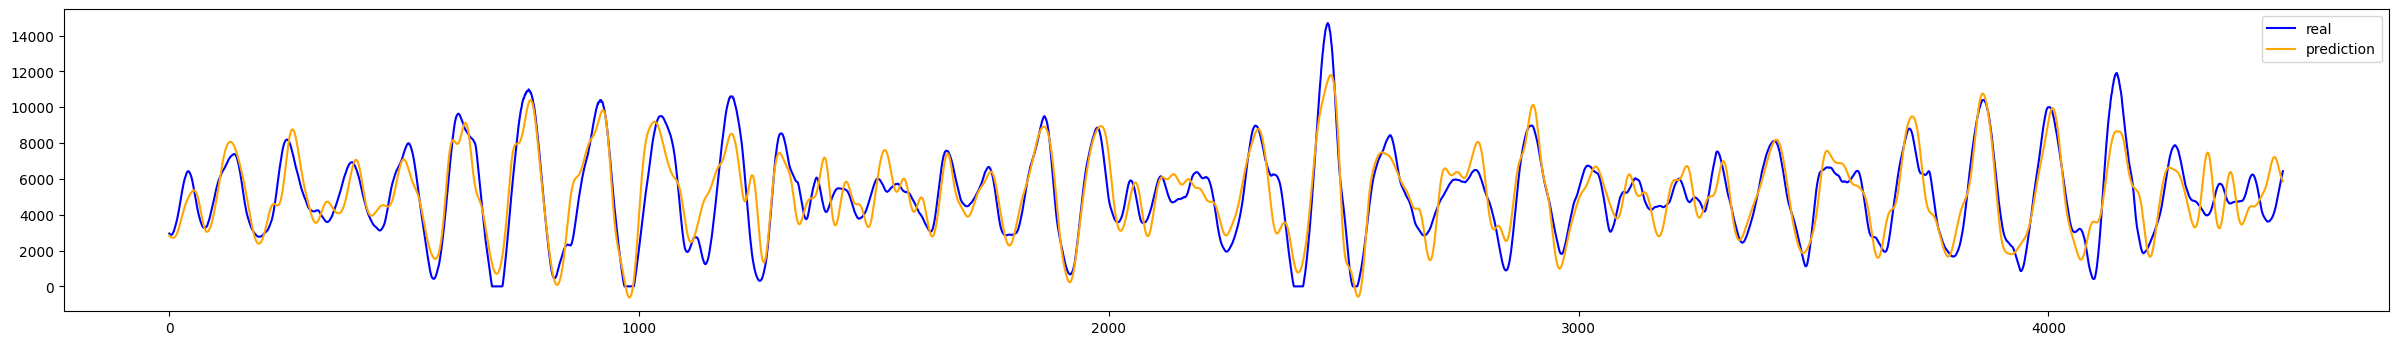

In [20]:
fan_force150_real1,fan_force150_pre1 = FanGuiHua_force1(valid50_y_Force1,N_pre50_Y_Force1)

np.savetxt('force1500_步长10_混合注意力.csv',np.hstack((fan_force150_real1,fan_force150_pre1)),delimiter=',')

In [21]:
# 输入50步长输出1步长Force2
force250_scaled1 = deal_data2(np.hstack((Heave,Surge,Pitch,Force2))[3500:,:], 4, 509)
force250_x1,force250_y1 = split_sequence(force250_scaled1, 500)
# print(force150_x1.shape)
# 输入100步长输出1步长
# force1100_scaled1 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[300:,:], 4, 100)
# force1100_x1,force1100_y1 = split_sequence(force1100_scaled1, 100)
# print(force1100_x1.shape)

In [22]:
train_force250_x1, train_force250_y1, valid_force250_x1, valid_force250_y1 = split_train_valid(force250_x1,force250_y1, 4500, 7500, 12000)
train50_x_Force2, valid50_x_Force2 = np.hstack((pretrain_heave50_Y1, pretrain_surge50_Y1, pretrain_pitch50_Y1)), np.hstack((pre_heave50_Y1, pre_surge50_Y1, pre_pitch50_Y1))
train50_y_Force2, valid50_y_Force2 = train_force250_y1, valid_force250_y1

In [23]:
N_model50_Force2, N_history50_Force2, N_pre50_train_Y_Force2, N_pre50_Y_Force2 = Model_NN(train50_x_Force2, train50_y_Force2, valid50_x_Force2, valid50_y_Force2, lr=0.01, epochs=1000, batch_size=256)

Train on 3000 samples, validate on 4500 samples
Epoch 1/1000
 - 0s - loss: 0.0158 - val_loss: 0.0305
Epoch 2/1000
 - 0s - loss: 0.0072 - val_loss: 0.0328
Epoch 3/1000
 - 0s - loss: 0.0099 - val_loss: 0.0204
Epoch 4/1000
 - 0s - loss: 0.0069 - val_loss: 0.0227
Epoch 5/1000
 - 0s - loss: 0.0055 - val_loss: 0.0245
Epoch 6/1000
 - 0s - loss: 0.0062 - val_loss: 0.0223
Epoch 7/1000
 - 0s - loss: 0.0055 - val_loss: 0.0233
Epoch 8/1000
 - 0s - loss: 0.0056 - val_loss: 0.0235
Epoch 9/1000
 - 0s - loss: 0.0056 - val_loss: 0.0229
Epoch 10/1000
 - 0s - loss: 0.0055 - val_loss: 0.0232
Epoch 11/1000
 - 0s - loss: 0.0055 - val_loss: 0.0232
Epoch 12/1000
 - 0s - loss: 0.0054 - val_loss: 0.0231
Epoch 13/1000
 - 0s - loss: 0.0054 - val_loss: 0.0231
Epoch 14/1000
 - 0s - loss: 0.0053 - val_loss: 0.0230
Epoch 15/1000
 - 0s - loss: 0.0053 - val_loss: 0.0229
Epoch 16/1000
 - 0s - loss: 0.0053 - val_loss: 0.0229
Epoch 17/1000
 - 0s - loss: 0.0052 - val_loss: 0.0228
Epoch 18/1000
 - 0s - loss: 0.0052 - val_lo

 - 0s - loss: 0.0048 - val_loss: 0.0223
Epoch 152/1000
 - 0s - loss: 0.0047 - val_loss: 0.0223
Epoch 153/1000
 - 0s - loss: 0.0047 - val_loss: 0.0223
Epoch 154/1000
 - 0s - loss: 0.0047 - val_loss: 0.0223
Epoch 155/1000
 - 0s - loss: 0.0047 - val_loss: 0.0223
Epoch 156/1000
 - 0s - loss: 0.0047 - val_loss: 0.0223
Epoch 157/1000
 - 0s - loss: 0.0047 - val_loss: 0.0223
Epoch 158/1000
 - 0s - loss: 0.0047 - val_loss: 0.0223
Epoch 159/1000
 - 0s - loss: 0.0047 - val_loss: 0.0223
Epoch 160/1000
 - 0s - loss: 0.0047 - val_loss: 0.0223
Epoch 161/1000
 - 0s - loss: 0.0047 - val_loss: 0.0223
Epoch 162/1000
 - 0s - loss: 0.0047 - val_loss: 0.0223
Epoch 163/1000
 - 0s - loss: 0.0047 - val_loss: 0.0223
Epoch 164/1000
 - 0s - loss: 0.0047 - val_loss: 0.0223
Epoch 165/1000
 - 0s - loss: 0.0047 - val_loss: 0.0223
Epoch 166/1000
 - 0s - loss: 0.0047 - val_loss: 0.0223
Epoch 167/1000
 - 0s - loss: 0.0047 - val_loss: 0.0223
Epoch 168/1000
 - 0s - loss: 0.0047 - val_loss: 0.0223
Epoch 169/1000
 - 0s - lo

 - 0s - loss: 0.0046 - val_loss: 0.0222
Epoch 301/1000
 - 0s - loss: 0.0046 - val_loss: 0.0222
Epoch 302/1000
 - 0s - loss: 0.0046 - val_loss: 0.0222
Epoch 303/1000
 - 0s - loss: 0.0047 - val_loss: 0.0222
Epoch 304/1000
 - 0s - loss: 0.0047 - val_loss: 0.0222
Epoch 305/1000
 - 0s - loss: 0.0046 - val_loss: 0.0222
Epoch 306/1000
 - 0s - loss: 0.0046 - val_loss: 0.0222
Epoch 307/1000
 - 0s - loss: 0.0046 - val_loss: 0.0222
Epoch 308/1000
 - 0s - loss: 0.0046 - val_loss: 0.0222
Epoch 309/1000
 - 0s - loss: 0.0046 - val_loss: 0.0222
Epoch 310/1000
 - 0s - loss: 0.0046 - val_loss: 0.0222
Epoch 311/1000
 - 0s - loss: 0.0046 - val_loss: 0.0222
Epoch 312/1000
 - 0s - loss: 0.0046 - val_loss: 0.0222
Epoch 313/1000
 - 0s - loss: 0.0046 - val_loss: 0.0222
Epoch 314/1000
 - 0s - loss: 0.0046 - val_loss: 0.0222
Epoch 315/1000
 - 0s - loss: 0.0046 - val_loss: 0.0222
Epoch 316/1000
 - 0s - loss: 0.0046 - val_loss: 0.0222
Epoch 317/1000
 - 0s - loss: 0.0046 - val_loss: 0.0222
Epoch 318/1000
 - 0s - lo

 - 0s - loss: 0.0046 - val_loss: 0.0222
Epoch 450/1000
 - 0s - loss: 0.0046 - val_loss: 0.0222
Epoch 451/1000
 - 0s - loss: 0.0046 - val_loss: 0.0222
Epoch 452/1000
 - 0s - loss: 0.0046 - val_loss: 0.0222
Epoch 453/1000
 - 0s - loss: 0.0046 - val_loss: 0.0222
Epoch 454/1000
 - 0s - loss: 0.0046 - val_loss: 0.0222
Epoch 455/1000
 - 0s - loss: 0.0046 - val_loss: 0.0223
Epoch 456/1000
 - 0s - loss: 0.0046 - val_loss: 0.0223
Epoch 457/1000
 - 0s - loss: 0.0047 - val_loss: 0.0223
Epoch 458/1000
 - 0s - loss: 0.0047 - val_loss: 0.0223
Epoch 459/1000
 - 0s - loss: 0.0047 - val_loss: 0.0223
Epoch 460/1000
 - 0s - loss: 0.0047 - val_loss: 0.0223
Epoch 461/1000
 - 0s - loss: 0.0047 - val_loss: 0.0223
Epoch 462/1000
 - 0s - loss: 0.0047 - val_loss: 0.0223
Epoch 463/1000
 - 0s - loss: 0.0047 - val_loss: 0.0222
Epoch 464/1000
 - 0s - loss: 0.0047 - val_loss: 0.0220
Epoch 465/1000
 - 0s - loss: 0.0046 - val_loss: 0.0222
Epoch 466/1000
 - 0s - loss: 0.0045 - val_loss: 0.0222
Epoch 467/1000
 - 0s - lo

 - 0s - loss: 0.0043 - val_loss: 0.0230
Epoch 599/1000
 - 0s - loss: 0.0043 - val_loss: 0.0230
Epoch 600/1000
 - 0s - loss: 0.0043 - val_loss: 0.0230
Epoch 601/1000
 - 0s - loss: 0.0042 - val_loss: 0.0230
Epoch 602/1000
 - 0s - loss: 0.0042 - val_loss: 0.0231
Epoch 603/1000
 - 0s - loss: 0.0042 - val_loss: 0.0231
Epoch 604/1000
 - 0s - loss: 0.0042 - val_loss: 0.0231
Epoch 605/1000
 - 0s - loss: 0.0042 - val_loss: 0.0231
Epoch 606/1000
 - 0s - loss: 0.0042 - val_loss: 0.0231
Epoch 607/1000
 - 0s - loss: 0.0042 - val_loss: 0.0231
Epoch 608/1000
 - 0s - loss: 0.0042 - val_loss: 0.0232
Epoch 609/1000
 - 0s - loss: 0.0042 - val_loss: 0.0232
Epoch 610/1000
 - 0s - loss: 0.0042 - val_loss: 0.0232
Epoch 611/1000
 - 0s - loss: 0.0042 - val_loss: 0.0232
Epoch 612/1000
 - 0s - loss: 0.0042 - val_loss: 0.0234
Epoch 613/1000
 - 0s - loss: 0.0042 - val_loss: 0.0241
Epoch 614/1000
 - 0s - loss: 0.0043 - val_loss: 0.0249
Epoch 615/1000
 - 0s - loss: 0.0044 - val_loss: 0.0249
Epoch 616/1000
 - 0s - lo

 - 0s - loss: 0.0038 - val_loss: 0.0226
Epoch 748/1000
 - 0s - loss: 0.0038 - val_loss: 0.0226
Epoch 749/1000
 - 0s - loss: 0.0038 - val_loss: 0.0226
Epoch 750/1000
 - 0s - loss: 0.0038 - val_loss: 0.0225
Epoch 751/1000
 - 0s - loss: 0.0038 - val_loss: 0.0225
Epoch 752/1000
 - 0s - loss: 0.0038 - val_loss: 0.0225
Epoch 753/1000
 - 0s - loss: 0.0038 - val_loss: 0.0225
Epoch 754/1000
 - 0s - loss: 0.0038 - val_loss: 0.0225
Epoch 755/1000
 - 0s - loss: 0.0038 - val_loss: 0.0226
Epoch 756/1000
 - 0s - loss: 0.0038 - val_loss: 0.0228
Epoch 757/1000
 - 0s - loss: 0.0039 - val_loss: 0.0233
Epoch 758/1000
 - 0s - loss: 0.0039 - val_loss: 0.0234
Epoch 759/1000
 - 0s - loss: 0.0039 - val_loss: 0.0231
Epoch 760/1000
 - 0s - loss: 0.0039 - val_loss: 0.0230
Epoch 761/1000
 - 0s - loss: 0.0039 - val_loss: 0.0232
Epoch 762/1000
 - 0s - loss: 0.0039 - val_loss: 0.0233
Epoch 763/1000
 - 0s - loss: 0.0039 - val_loss: 0.0233
Epoch 764/1000
 - 0s - loss: 0.0039 - val_loss: 0.0232
Epoch 765/1000
 - 0s - lo

 - 0s - loss: 0.0039 - val_loss: 0.0220
Epoch 897/1000
 - 0s - loss: 0.0039 - val_loss: 0.0219
Epoch 898/1000
 - 0s - loss: 0.0038 - val_loss: 0.0218
Epoch 899/1000
 - 0s - loss: 0.0038 - val_loss: 0.0218
Epoch 900/1000
 - 0s - loss: 0.0037 - val_loss: 0.0218
Epoch 901/1000
 - 0s - loss: 0.0037 - val_loss: 0.0218
Epoch 902/1000
 - 0s - loss: 0.0037 - val_loss: 0.0219
Epoch 903/1000
 - 0s - loss: 0.0037 - val_loss: 0.0219
Epoch 904/1000
 - 0s - loss: 0.0037 - val_loss: 0.0218
Epoch 905/1000
 - 0s - loss: 0.0037 - val_loss: 0.0218
Epoch 906/1000
 - 0s - loss: 0.0037 - val_loss: 0.0218
Epoch 907/1000
 - 0s - loss: 0.0037 - val_loss: 0.0218
Epoch 908/1000
 - 0s - loss: 0.0037 - val_loss: 0.0218
Epoch 909/1000
 - 0s - loss: 0.0037 - val_loss: 0.0218
Epoch 910/1000
 - 0s - loss: 0.0037 - val_loss: 0.0218
Epoch 911/1000
 - 0s - loss: 0.0037 - val_loss: 0.0218
Epoch 912/1000
 - 0s - loss: 0.0037 - val_loss: 0.0218
Epoch 913/1000
 - 0s - loss: 0.0037 - val_loss: 0.0218
Epoch 914/1000
 - 0s - lo

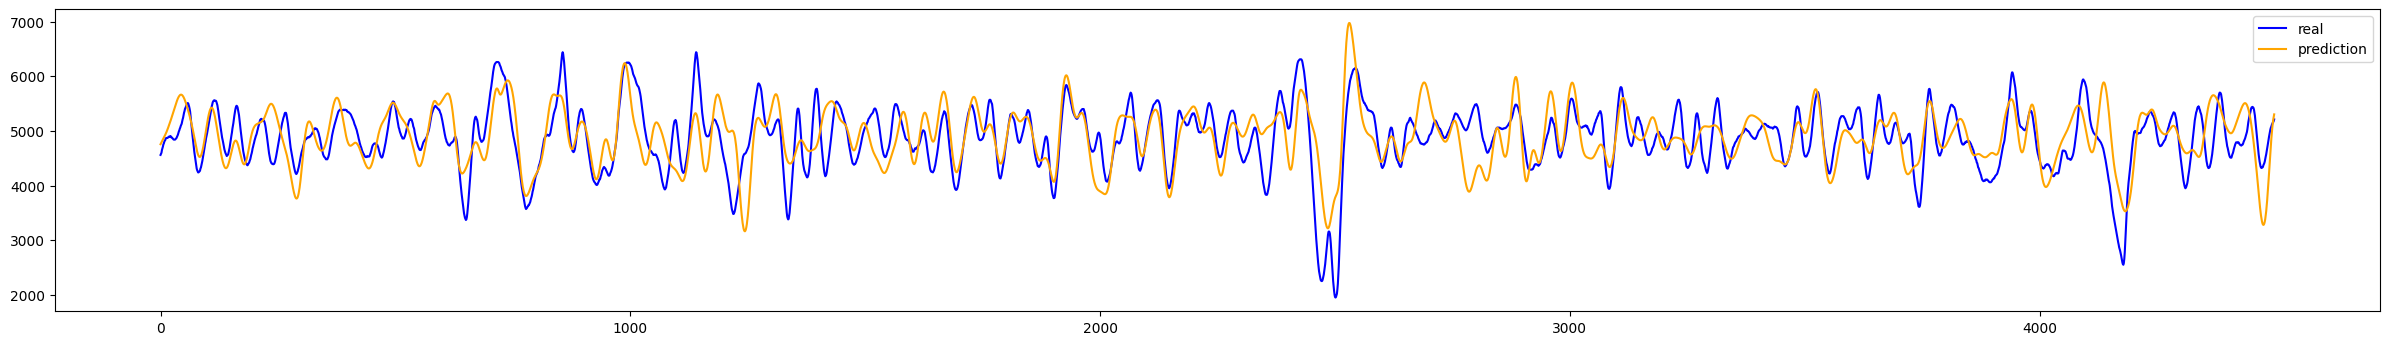

In [24]:
fan_force250_real1,fan_force250_pre1 = FanGuiHua_force2(valid50_y_Force2,N_pre50_Y_Force2)

np.savetxt('force2500_步长10_混合注意力.csv',np.hstack((fan_force250_real1,fan_force250_pre1)),delimiter=',')

In [25]:
RNSE(valid50_y_Force1,N_pre50_Y_Force1)
Acc(valid50_y_Force1,N_pre50_Y_Force1)

RMSE(sklearn): 0.1538604961606318
Acc: 0.9231527464387886


In [26]:
RNSE(valid50_y_Force2,N_pre50_Y_Force2)
Acc(valid50_y_Force2,N_pre50_Y_Force2)

RMSE(sklearn): 0.14768781809904136
Acc: 0.9356946141210402
